# City-Balanced EDA

Dataset:

`data/processed/dataset_city_balanced_eda.csv`

Purpose:

Explore the urban dataset before training any model.

Each row is one 500m x 500m city patch.

Each column is a measured urban feature, such as:

- street density
- building coverage
- public space
- POI density
- terrain slope
- street-direction entropy

Important:

This dataset is balanced by city.

It has 250 patches per city.

It is not yet balanced by Urban Atlas class because the Urban Atlas labels are still missing.

Imports

In [2]:
# Pandas is used to read and work with tables.
# In this project, each CSV file is a table of urban patches.
import pandas as pd

# Matplotlib is used to draw simple charts.
# We use it for histograms, bar charts, scatter plots, and PCA plots.
import matplotlib.pyplot as plt

# Path helps us write file paths in a safer way.
# It works better across different operating systems.
from pathlib import Path

# StandardScaler prepares numerical data for PCA.
# It puts all selected features on a comparable scale.
# Example:
# building_coverage may be between 0 and 1,
# while poi_density can be much larger.
# Scaling prevents large-number features from dominating the analysis.
from sklearn.preprocessing import StandardScaler

# PCA means Principal Component Analysis.
# It reduces many numerical features into two visual axes.
# This helps us see patterns in the dataset.
from sklearn.decomposition import PCA

Load Dataset

In [3]:
# This is the path to the city-balanced EDA dataset.
# It contains 2,000 rows:
# 8 cities x 250 patches per city.
DATA_PATH = Path("../data/processed/dataset_city_balanced_eda.csv")

# Sometimes VS Code runs the notebook from the repo root.
# Sometimes it runs from inside the notebooks folder.
# This fallback checks the second possible path.
if not DATA_PATH.exists():
    DATA_PATH = Path("data/processed/dataset_city_balanced_eda.csv")

# Read the CSV file into a pandas DataFrame.
# A DataFrame is like an Excel table inside Python.
df = pd.read_csv(DATA_PATH)

# Print the number of rows and columns.
# Rows = urban patches.
# Columns = metadata + measured features.
print("Rows:", len(df))
print("Columns:", len(df.columns))

# Show the first five rows.
# This helps us verify that the file loaded correctly.
df.head()

Rows: 2000
Columns: 44


,patch_id,city,code,lat,lon,n_nodes,n_edges,mean_node_degree,dead_end_ratio,proportion_3way,...,pct_food_drink,pct_retail,pct_civic,pct_culture,pct_transport,pct_services,entropy_raw,entropy_normalised,dominant_bearing,n_dominant_peaks
0,amsterdam_03315,"Amsterdam, Netherlands",amsterdam,52.404937,4.762091,17,42,4.9412,0.0,0.0,...,0.0000,0.4000,0.0000,0.000,0.0000,0.0000,1.870400,0.521945,50.0,5
1,amsterdam_01681,"Amsterdam, Netherlands",amsterdam,52.362144,4.832175,98,248,5.0612,0.0,0.0,...,0.0455,0.0000,0.0909,0.000,0.1364,0.0000,1.736680,0.484630,85.0,2
2,amsterdam_02370,"Amsterdam, Netherlands",amsterdam,52.380162,4.806355,104,254,4.8846,0.0,0.0,...,0.0000,0.1111,0.0000,0.037,0.2593,0.0000,2.052959,0.572889,85.0,4
3,amsterdam_02382,"Amsterdam, Netherlands",amsterdam,52.380162,4.850619,132,338,5.1212,0.0,0.0,...,0.2237,0.5132,0.0132,0.000,0.0526,0.0263,2.351600,0.656226,160.0,6
4,amsterdam_04133,"Amsterdam, Netherlands",amsterdam,52.425207,4.891193,52,122,4.6923,0.0,0.0,...,0.0000,0.0833,0.0000,0.000,0.0000,0.0000,2.305767,0.643436,155.0,6


Check city balance

In [4]:
# Count how many patches we have for each city.
# This checks whether the EDA dataset is balanced by city.
df["code"].value_counts().sort_index()

code
amsterdam    250
barcelona    250
prague       250
riga         250
sarajevo     250
skopje       250
vienna       250
warsaw       250
Name: count, dtype: int64

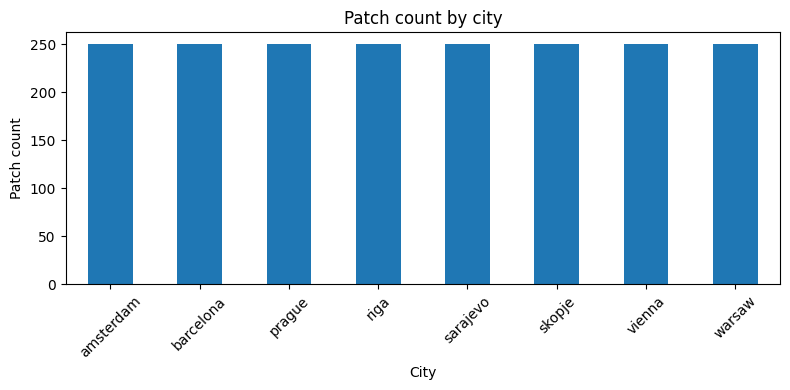

In [5]:
# Store the city counts in a variable.
city_counts = df["code"].value_counts().sort_index()

# Create a new chart.
plt.figure(figsize=(8, 4))

# Draw a bar chart.
# Each bar is one city.
# The height is the number of patches.
city_counts.plot(kind="bar")

# Add chart title and axis labels.
plt.title("Patch count by city")
plt.xlabel("City")
plt.ylabel("Patch count")

# Rotate city names so they are readable.
plt.xticks(rotation=45)

# Adjust spacing so labels are not cut off.
plt.tight_layout()

# Display the chart in the notebook.
plt.show()

Define key features

# These are the first features we want to inspect visually.
# We do not use all columns yet.
# We start with a small, readable set.

KEY_FEATURES = [
    # How many intersections exist per square kilometer.
    # Higher values suggest finer urban grain.
    "intersection_density",

    # Total street length per square kilometer.
    # Higher values suggest a denser street network.
    "network_density",

    # Share of street nodes that are dead ends.
    # Higher values may suggest suburban or fragmented networks.
    "dead_end_ratio",

    # Share of four-way intersections.
    # Higher values may suggest grid-like street patterns.
    "proportion_4way",

    # Share of the patch covered by building footprints.
    # Higher values suggest denser built fabric.
    "building_coverage",

    # Share of the patch covered by mapped public open space.
    # This includes parks, grass areas, and pedestrian zones.
    "public_space_ratio",

    # Number of mapped points of interest per square kilometer.
    # POIs include shops, cafés, schools, services, transport points, etc.
    "poi_density",

    # Diversity of POI categories.
    # Higher values suggest a more mixed-use patch.
    "functional_entropy",

    # Average terrain slope in degrees.
    # Higher values suggest hilly or topographically constrained areas.
    "mean_slope_deg",

    # Diversity of street directions.
    # Lower values suggest a clear grid.
    # Higher values suggest irregular or multi-directional streets.
    "entropy_normalised",
]

# Summarize the selected features.
# count = number of values
# mean = average
# std = variation
# min/max = lowest/highest value
# 25%, 50%, 75% = distribution checkpoints
df[KEY_FEATURES].describe().T

Quality Check

In [6]:
# This table checks possible data-quality problems by city.
# It does not judge morphology directly.
# It checks whether OpenStreetMap may be missing buildings or POIs.

quality = pd.DataFrame({
    # Total patches per city.
    "total_patches": df.groupby("code").size(),

    # Count patches where building_count equals zero.
    # A zero-building patch in an urban area may mean missing OSM building data.
    "zero_building_patches": df.groupby("code")["building_count"].apply(lambda x: (x == 0).sum()),

    # Count patches where poi_count equals zero.
    # A zero-POI patch may mean missing OSM activity data.
    "zero_poi_patches": df.groupby("code")["poi_count"].apply(lambda x: (x == 0).sum()),
})

# Convert counts into ratios.
# Example:
# 25 zero-building patches out of 250 = 0.10
quality["zero_building_ratio"] = quality["zero_building_patches"] / quality["total_patches"]
quality["zero_poi_ratio"] = quality["zero_poi_patches"] / quality["total_patches"]

# Show the quality table.
quality

,total_patches,zero_building_patches,zero_poi_patches,zero_building_ratio,zero_poi_ratio
code,,,,,
amsterdam,250,3,13,0.012,0.052
barcelona,250,0,10,0.000,0.040
prague,250,250,18,1.000,0.072
riga,250,14,60,0.056,0.240
sarajevo,250,0,41,0.000,0.164
skopje,250,4,61,0.016,0.244
vienna,250,250,9,1.000,0.036
warsaw,250,250,33,1.000,0.132


In [ ]:
Histogram

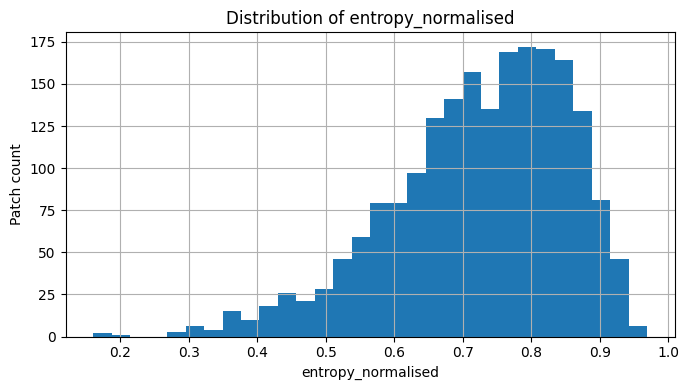

In [7]:
# Choose one feature to inspect.
# You can change this feature name and rerun the cell.
feature = "entropy_normalised"

# Create a new chart.
plt.figure(figsize=(7, 4))

# Draw a histogram.
# A histogram shows how values are distributed.
# It answers:
# Are most patches low, medium, or high for this feature?
df[feature].hist(bins=30)

# Add chart labels.
plt.title(f"Distribution of {feature}")
plt.xlabel(feature)
plt.ylabel("Patch count")

# Clean layout.
plt.tight_layout()

# Show the chart.
plt.show()

Boxplot by city

<Figure size 900x500 with 0 Axes>

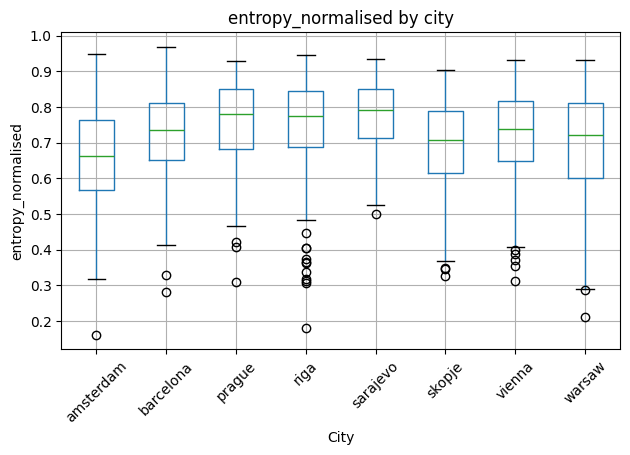

In [8]:
# Choose one feature to compare across cities.
feature = "entropy_normalised"

# Create a new chart.
plt.figure(figsize=(9, 5))

# A boxplot shows the spread of values by city.
# It helps compare cities without showing every point.
#
# Middle line = median value.
# Box = middle 50% of values.
# Dots or long lines = possible outliers.
df.boxplot(column=feature, by="code", rot=45)

# Add chart labels.
plt.title(f"{feature} by city")
plt.suptitle("")  # removes automatic pandas title
plt.xlabel("City")
plt.ylabel(feature)

# Clean layout.
plt.tight_layout()

# Show the chart.
plt.show()

Two feature Scatter plot

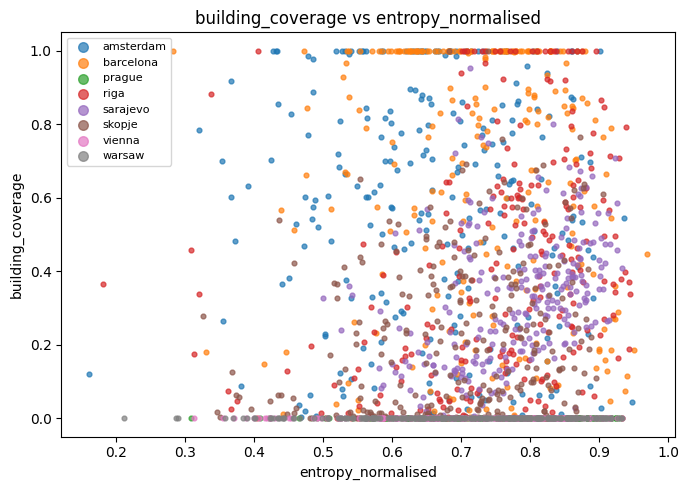

In [9]:
# Choose two features to compare.
# x_col is the horizontal axis.
# y_col is the vertical axis.

x_col = "entropy_normalised"
y_col = "building_coverage"

# Create a new chart.
plt.figure(figsize=(7, 5))

# Plot each city separately.
# This lets us color the points by city.
for code, group in df.groupby("code"):
    plt.scatter(
        group[x_col],
        group[y_col],
        s=12,          # point size
        alpha=0.7,     # transparency
        label=code     # city label
    )

# Add chart labels.
plt.title(f"{y_col} vs {x_col}")
plt.xlabel(x_col)
plt.ylabel(y_col)

# Show legend.
plt.legend(markerscale=2, fontsize=8)

# Clean layout.
plt.tight_layout()

# Show chart.
plt.show()

Correlation matrix

In [20]:
# Correlation checks whether selected features move together.
#
# +1 means they increase together.
#  0 means no clear linear relation.
# -1 means one increases while the other decreases.
#
# Strong correlation may mean two columns repeat similar information.

KEY_FEATURES = [
    "intersection_density",
    "network_density",
    "proportion_4way",
    "building_coverage",
    "public_space_ratio",
    "poi_density",
    "functional_entropy",
    "mean_slope_deg",
    "entropy_normalised",
]

corr = df[KEY_FEATURES].corr()

corr

,intersection_density,network_density,proportion_4way,building_coverage,public_space_ratio,poi_density,functional_entropy,mean_slope_deg,entropy_normalised
intersection_density,1.000000,0.915765,-0.547220,0.299820,0.303846,0.500010,0.362222,-0.143821,0.322515
network_density,0.915765,1.000000,-0.516056,0.409023,0.299474,0.534484,0.433937,-0.087067,0.355412
proportion_4way,-0.547220,-0.516056,1.000000,-0.176870,-0.272804,-0.263545,-0.301285,0.194405,-0.290434
building_coverage,0.299820,0.409023,-0.176870,1.000000,0.065819,0.379307,0.310582,-0.062987,0.022602
public_space_ratio,0.303846,0.299474,-0.272804,0.065819,1.000000,0.184533,0.078011,-0.169212,0.157004
poi_density,0.500010,0.534484,-0.263545,0.379307,0.184533,1.000000,0.249638,-0.057313,0.117382
functional_entropy,0.362222,0.433937,-0.301285,0.310582,0.078011,0.249638,1.000000,-0.106788,0.170956
mean_slope_deg,-0.143821,-0.087067,0.194405,-0.062987,-0.169212,-0.057313,-0.106788,1.000000,0.241222
entropy_normalised,0.322515,0.355412,-0.290434,0.022602,0.157004,0.117382,0.170956,0.241222,1.000000


In [21]:
df["intersection_density"].corr(df["network_density"])

np.float64(0.9157648721334032)

In [22]:
threshold = 0.85

strong_pairs = []

features = list(corr.columns)

for i in range(len(features)):
    for j in range(i + 1, len(features)):
        feature_1 = features[i]
        feature_2 = features[j]
        value = corr.loc[feature_1, feature_2]

        if abs(value) >= threshold:
            strong_pairs.append({
                "feature_1": feature_1,
                "feature_2": feature_2,
                "correlation": round(value, 3)
            })

strong_corr_df = pd.DataFrame(strong_pairs)

strong_corr_df

,feature_1,feature_2,correlation
0,intersection_density,network_density,0.916


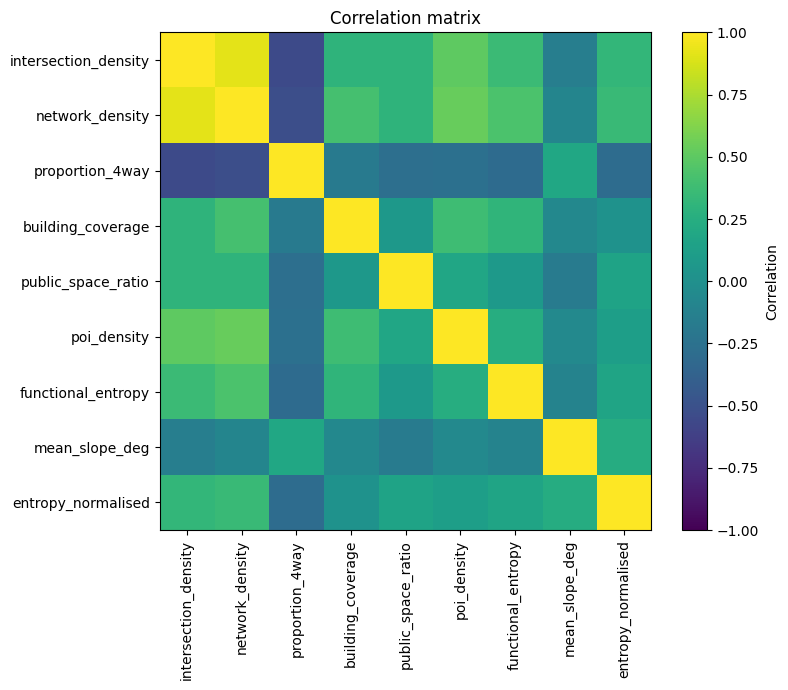

In [24]:
# Create a new chart.
plt.figure(figsize=(8, 7))

# Draw the correlation matrix as an image.
# Yellow means strong positive correlation.
# Purple means strong negative correlation.
# Green/blue means weak or moderate relation.
plt.imshow(corr, aspect="auto", vmin=-1, vmax=1)

# Add a color scale.
plt.colorbar(label="Correlation")

# Add feature names to both axes.
plt.xticks(range(len(KEY_FEATURES)), KEY_FEATURES, rotation=90)
plt.yticks(range(len(KEY_FEATURES)), KEY_FEATURES)

# Add title.
plt.title("Correlation matrix")

# Clean layout.
plt.tight_layout()

# Show chart.
plt.show()

# Show only strong correlation pairs.
# This is easier to read than the full matrix.
threshold = 0.85

strong_pairs = []
features = list(corr.columns)

for i in range(len(features)):
    for j in range(i + 1, len(features)):
        feature_1 = features[i]
        feature_2 = features[j]
        value = corr.loc[feature_1, feature_2]

        if abs(value) >= threshold:
            strong_pairs.append({
                "feature_1": feature_1,
                "feature_2": feature_2,
                "correlation": round(value, 3)
            })

strong_corr_df = pd.DataFrame(strong_pairs)

if strong_corr_df.empty:
    print("No feature pairs have correlation above 0.85.")
else:
    strong_corr_df

PCA setup

In [12]:
# PCA turns many features into two visual axes.
# It is useful when the dataset has many columns.
#
# PC1 = first main direction of variation.
# PC2 = second main direction of variation.
#
# This does not create labels.
# It only helps visualize patterns.

# Copy only the selected numerical features.
feature_df = df[KEY_FEATURES].copy()

# If any feature has missing values, replace them with the median.
# This prevents PCA from failing.
feature_df = feature_df.fillna(feature_df.median())

# Scale features so they are comparable.
# Without scaling, large-number columns dominate PCA.
scaler = StandardScaler()
X_scaled = scaler.fit_transform(feature_df)

# Create PCA with 2 components.
# We want a 2D plot.
pca = PCA(n_components=2, random_state=42)

# Apply PCA to the scaled feature table.
X_pca = pca.fit_transform(X_scaled)

# Store PCA coordinates in a new table.
pca_df = pd.DataFrame({
    "PC1": X_pca[:, 0],
    "PC2": X_pca[:, 1],
    "code": df["code"].values,
    "city": df["city"].values,
    "patch_id": df["patch_id"].values,
})

# Show how much variation PC1 and PC2 explain.
print("Explained variance:", pca.explained_variance_ratio_)

# Preview PCA table.
pca_df.head()

Explained variance: [0.38280166 0.13983892]


,PC1,PC2,code,city,patch_id
0,-0.391612,-1.952998,amsterdam,"Amsterdam, Netherlands",amsterdam_03315
1,-0.097018,-1.915948,amsterdam,"Amsterdam, Netherlands",amsterdam_01681
2,0.775617,-1.637846,amsterdam,"Amsterdam, Netherlands",amsterdam_02370
3,0.846385,-1.141254,amsterdam,"Amsterdam, Netherlands",amsterdam_02382
4,-1.238005,-0.846137,amsterdam,"Amsterdam, Netherlands",amsterdam_04133


PCA plot by city

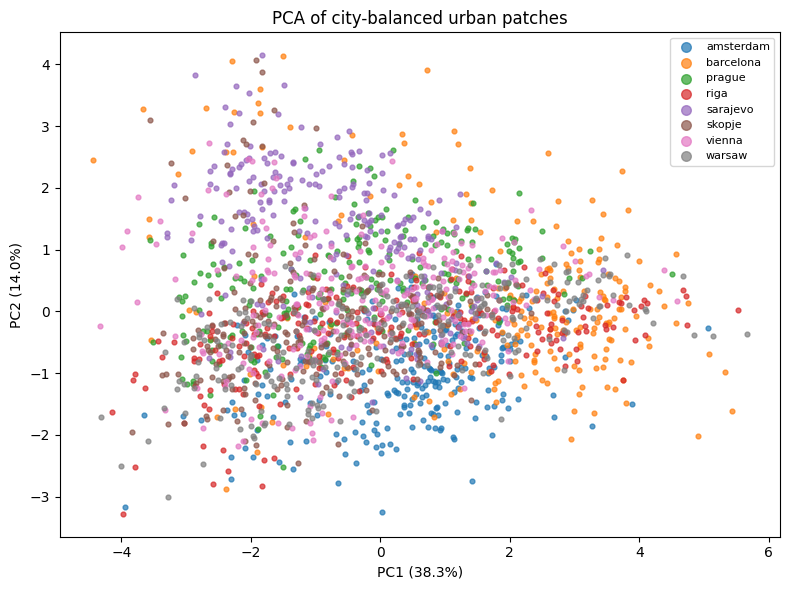

In [13]:
# Create a new chart.
plt.figure(figsize=(8, 6))

# Plot PCA points city by city.
# Each point is one 500m x 500m patch.
for code, group in pca_df.groupby("code"):
    plt.scatter(
        group["PC1"],
        group["PC2"],
        s=12,
        alpha=0.7,
        label=code
    )

# Add title and axis labels.
plt.title("PCA of city-balanced urban patches")
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%})")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%})")

# Add legend.
plt.legend(markerscale=2, fontsize=8)

# Clean layout.
plt.tight_layout()

# Show chart.
plt.show()

PCA feature loadings

In [14]:
# PCA loadings tell us which features shape PC1 and PC2.
#
# A high positive value means the feature pushes patches
# in the positive direction of that PCA axis.
#
# A high negative value means the feature pushes patches
# in the opposite direction.

loadings = pd.DataFrame(
    pca.components_.T,
    columns=["PC1", "PC2"],
    index=KEY_FEATURES
)

# Sort features by influence on PC1.
loadings.sort_values("PC1", ascending=False)

,PC1,PC2
network_density,0.494116,6.467673e-02
intersection_density,0.478473,3.639315e-02
poi_density,0.347702,-8.514947e-02
functional_entropy,0.300340,-6.314713e-02
building_coverage,0.270384,-2.001746e-01
public_space_ratio,0.224775,-9.306767e-02
entropy_normalised,0.223347,6.470167e-01
dead_end_ratio,-0.000000,9.714451e-17
mean_slope_deg,-0.096483,7.182517e-01
proportion_4way,-0.364676,2.648113e-03


In [15]:
# Sort features by influence on PC2.
loadings.sort_values("PC2", ascending=False)

,PC1,PC2
mean_slope_deg,-0.096483,7.182517e-01
entropy_normalised,0.223347,6.470167e-01
network_density,0.494116,6.467673e-02
intersection_density,0.478473,3.639315e-02
proportion_4way,-0.364676,2.648113e-03
dead_end_ratio,-0.000000,9.714451e-17
functional_entropy,0.300340,-6.314713e-02
poi_density,0.347702,-8.514947e-02
public_space_ratio,0.224775,-9.306767e-02
building_coverage,0.270384,-2.001746e-01


Save selected visuals

<Figure size 900x500 with 0 Axes>

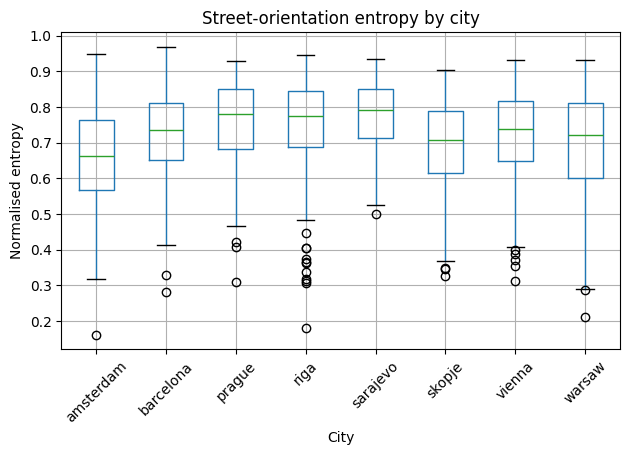

In [16]:
# Only save a plot if it tells a useful story.
# This avoids creating many random files.

OUTPUT_DIR = Path("../results/eda_city_balanced")

# Fallback path if VS Code runs from repo root.
if not OUTPUT_DIR.exists():
    OUTPUT_DIR = Path("results/eda_city_balanced")

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Example: save one selected boxplot.
feature = "entropy_normalised"

plt.figure(figsize=(9, 5))
df.boxplot(column=feature, by="code", rot=45)
plt.title("Street-orientation entropy by city")
plt.suptitle("")
plt.xlabel("City")
plt.ylabel("Normalised entropy")
plt.tight_layout()

# Save the figure.
plt.savefig(OUTPUT_DIR / "selected_entropy_by_city.png", dpi=200)

# Show the figure in the notebook too.
plt.show()

Notes

## Interpretation: entropy by city

What I see:

- [write one observation]
- [write one possible issue]
- [write one next check]

Architectural meaning:

- [example: higher entropy may indicate irregular street orientation]

Caution:

- This is city-balanced, not class-balanced.
- Urban Atlas labels are still missing.